<a href="https://colab.research.google.com/github/avindumihisara0229-code/ErgoSense/blob/Lochana/Visual_Stress_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
from google.colab import files
files.upload()


{}

In [59]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("archive")


In [60]:
!pip install opencv-python scikit-image

import os
import cv2
import numpy as np
from skimage.feature import hog


In [61]:
def extract_hog_features(image_path):
    image = cv2.imread(image_path)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    gray = cv2.resize(gray, (64, 64))

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    return features



In [62]:
X = []  # feature vectors
y = []  # labels

dataset_path = "archive"

for label in os.listdir(dataset_path):
    label_folder = os.path.join(dataset_path, label)

    for image_name in os.listdir(label_folder):
        image_path = os.path.join(label_folder, image_name)

        features = extract_hog_features(image_path)

        X.append(features)
        y.append(label)


In [63]:
X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

np.save("X_features.npy", X)
np.save("y_labels.npy", y)


Feature matrix shape: (5558, 1764)
Label vector shape: (5558,)


In [64]:
import numpy as np

X = np.load("X_features.npy")
y = np.load("y_labels.npy")


In [65]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)


In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [67]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)


SVC(kernel='linear', probability=True)

In [68]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=encoder.classes_))


Accuracy: 0.39568345323741005
              precision    recall  f1-score   support

       anger       0.29      0.40      0.33       178
    contempt       0.07      0.07      0.07        42
     disgust       0.17      0.16      0.16        88
        fear       0.33      0.35      0.34       114
   happiness       0.70      0.68      0.69       281
  neutrality       0.29      0.27      0.28       105
     sadness       0.27      0.24      0.25       149
    surprise       0.51      0.37      0.43       155

    accuracy                           0.40      1112
   macro avg       0.33      0.32      0.32      1112
weighted avg       0.41      0.40      0.40      1112



In [69]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.43345323741007197


In [70]:
import joblib

joblib.dump(svm_model, "svm_expression_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")


['label_encoder.pkl']

In [71]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


KNN Accuracy: 0.4028776978417266


In [72]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.4073741007194245


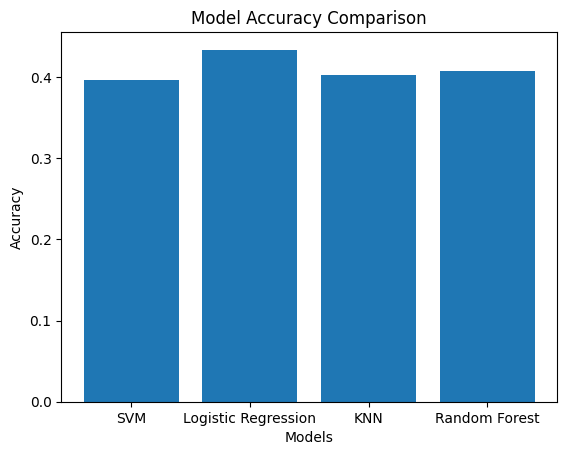

In [73]:
import matplotlib.pyplot as plt

models = [
    "SVM",
    "Logistic Regression",
    "KNN",
    "Random Forest"
]

accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


<Figure size 640x480 with 0 Axes>

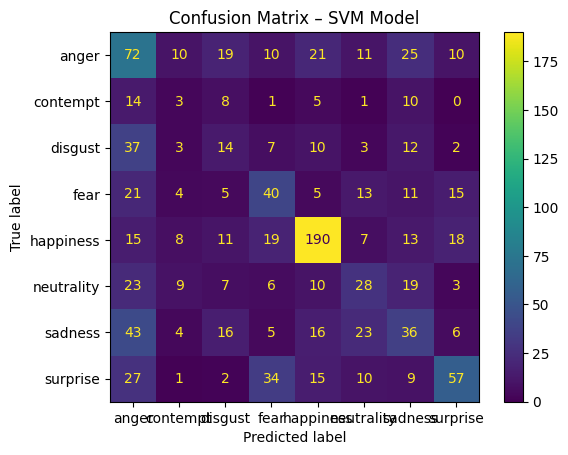

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

plt.figure()
disp.plot()
plt.title("Confusion Matrix – SVM Model")
plt.show()


In [75]:
import joblib

joblib.dump(knn_model, "knn_expression_model.pkl")
joblib.dump(rf_model, "rf_expression_model.pkl")


['rf_expression_model.pkl']